# Species voltages from a PyBaMM battery simulation

[PyBaMM](https://pybamm.org/) simulates lithium-ion batteries with the Doyle-Fuller-Newman (DFN) model: a "pseudo-2D" model where one dimension runs across the cell from anode to cathode, and the other runs radially inside each electrode particle. It captures the slow diffusion of lithium in the electrolyte and inside the active-material particles alike.

This notebook runs a standard DFN discharge and converts the outputs into **species voltages**,

$$ V_i = \bar\mu_i / (z_i F), $$

each species' electrochemical potential put on a voltage scale. These are the levels drawn in [electrochemical species band diagrams](https://marklundeberg.com/esbd/). At equilibrium, $V_{\mathrm{Li}^+}$ is exactly flat everywhere in the cell, so during discharge every slope and step in it is a specific dissipation mechanism, located and quantified. The conversions turn out to be nearly trivial, and along the way we pin down what the DFN's "electrolyte potential" actually is: $V_{\mathrm{Li}^+}$ wearing another name.

This is a companion to the [lithium-ion battery topic](https://marklundeberg.com/esbd/lib/) of my ESBD book; the simulation figures there come from this notebook.

In [1]:
%pip install "pybamm[plot,cite]" -q    # install PyBaMM if it is not installed
import numpy as np
import pybamm
import matplotlib.pyplot as plt
%config InlineBackend.figure_formats = ['svg']

## Note -- if you get Colab errors here (pip installation or mtrand ValueError),
## select "Runtime | Restart session and run all" from the menu bar, and it
## should run fine the second time.

Note: you may need to restart the kernel to use updated packages.


## 1. Run the simulation

We use the `Chen2020` parameter set (a graphite / NMC 811 cell, the LG M50; its measured OCV curves also appear in the book's equilibrium figure), and discharge it at a brisk 2C rate: nominally the full capacity in 30 minutes.

In [2]:
model = pybamm.lithium_ion.DFN()
param = pybamm.ParameterValues("Chen2020")

experiment = pybamm.Experiment(["Discharge at 2C for 1800 seconds"])
sim = pybamm.Simulation(model, parameter_values=param, experiment=experiment)
solution = sim.solve(initial_soc=1)

print(f"Simulated {solution.t[-1]:.0f} s of 2C discharge; "
      f"terminal voltage {solution['Voltage [V]'].entries[-1]:.3f} V at the end.")

Simulated 1800 s of 2C discharge; terminal voltage 1.711 V at the end.


In [3]:
# Constants and cell parameters we'll need throughout.
R = pybamm.constants.R.value       # 8.314 J/(mol K)
F = pybamm.constants.F.value       # 96485 C/mol
T = param["Ambient temperature [K]"]
t_plus = param["Cation transference number"]
TF = param["Thermodynamic factor"]              # = 1: this parameter set treats the electrolyte as ideal
c_ref = param["Initial concentration in electrolyte [mol.m-3]"]
L_n = param["Negative electrode thickness [m]"]
L_s = param["Separator thickness [m]"]
L_p = param["Positive electrode thickness [m]"]

print(f"T = {T} K,  t+ = {t_plus},  thermodynamic factor = {TF},  c_ref = {c_ref:.0f} mol/m^3")
print(f"cell thickness: {L_n*1e6:.1f} + {L_s*1e6:.1f} + {L_p*1e6:.1f} um (anode + separator + cathode)")

T = 298.15 K,  t+ = 0.2594,  thermodynamic factor = 1.0,  c_ref = 1000 mol/m^3
cell thickness: 85.2 + 12.0 + 75.6 um (anode + separator + cathode)


We'll examine a snapshot from partway through the discharge, then extract the fields we need: the electrolyte concentration and potential, the solid ("electrode") potentials, and the lithium concentration in the particles, both at the particle center and at the particle surface, all as functions of the through-cell position $x$.

In [4]:
t_snap = 1100  # seconds: ~60% of the way through the discharge, ~40% capacity remaining
it = np.argmin(np.abs(solution.t - t_snap))
t_snap = solution.t[it]

# Electrolyte fields (defined across the whole cell)
x_e   = solution["x [m]"].entries[:, it]
c_e   = solution["Electrolyte concentration [mol.m-3]"].entries[:, it]
phi_e = solution["Electrolyte potential [V]"].entries[:, it]

# Solid potentials (per electrode)
x_n   = solution["x_n [m]"].entries[:, it]
x_p   = solution["x_p [m]"].entries[:, it]
phi_s_n = solution["Negative electrode potential [V]"].entries[:, it]
phi_s_p = solution["Positive electrode potential [V]"].entries[:, it]

# Particle lithium concentrations: radial index 0 = center ("core"), -1 = surface
c_s_n = solution["Negative particle concentration [mol.m-3]"].entries[:, :, it]
c_s_p = solution["Positive particle concentration [mol.m-3]"].entries[:, :, it]
c_s_n_core, c_s_n_surf = c_s_n[0, :], c_s_n[-1, :]
c_s_p_core, c_s_p_surf = c_s_p[0, :], c_s_p[-1, :]

print(f"snapshot at t = {t_snap:.0f} s;  electrolyte concentration spans "
      f"{c_e.min():.0f} to {c_e.max():.0f} mol/m^3")

snapshot at t = 1095 s;  electrolyte concentration spans 105 to 3211 mol/m^3


## 2. From DFN outputs to species voltages

Species voltages need a zero, and we adopt two gauge choices that PyBaMM has, in effect, already made for us. First, potentials are referenced to the negative terminal, so our ground is the electrons in the negative current collector: $V_{\mathrm{e}^-} = 0$ there. Second, all the open-circuit-potential (OCP) functions are tabulated against a $\mathrm{Li}/\mathrm{Li}^+$ electrode, which is the same thing as setting $\mu_{\mathrm{Li(metal)}} = 0$ as the zero of lithium's chemical potential.

**Electrons.** The DFN's solid potential $\phi_s$ conducts ohmically and steps at interfaces by the Butler-Volmer overpotential; it is the electron electrochemical potential in disguise, as every "voltage" in a circuit is:

$$ V_{\mathrm{e}^-} = \phi_s. $$

**Lithium inside the particles.** Within a particle, $\mathrm{Li}^+$ and $\mathrm{e}^-$ coexist, and the local lithium content $c_s(r)$ sets the chemical potential of the stored (neutral) lithium. The OCP function is exactly that chemical potential on a voltage scale, $U(c_s) = -\mu_{\mathrm{Li}}(c_s)/F$; this is what "OCP versus $\mathrm{Li}/\mathrm{Li}^+$" means once $\mu_{\mathrm{Li(metal)}} = 0$. Splitting $\mu_{\mathrm{Li}} = \bar\mu_{\mathrm{Li}^+} + \bar\mu_{\mathrm{e}^-}$ pointwise:

$$ V_{\mathrm{Li}^+}(r) = \phi_s - U(c_s(r)). $$

The particle's electrons conduct well (one $\phi_s$ per particle), so the radial structure of $V_{\mathrm{Li}^+}$ comes entirely from the lithium concentration profile. We will draw the particle center ($r=0$, "core") and the particle surface.

**Lithium in the electrolyte.** Here is the subtle one. The DFN's "electrolyte potential" $\phi_e$ (Newman's $\Phi_2$) is not an electrostatic potential. In Newman's concentrated-solution theory it is *defined* operationally: $\phi_e$ at a point is the potential a hypothetical lithium reference electrode would read if dipped into the electrolyte there ([Doyle, Fuller & Newman 1993](https://doi.org/10.1149/1.2221597); the two rival definitions of electrolyte potential, and how to tell them apart, are dissected in [Bizeray, Howey & Monroe 2016](https://doi.org/10.1149/2.0451608jes)). Such a probe equilibrates the plating reaction $\mathrm{Li}^+ + \mathrm{e}^- \rightleftharpoons \mathrm{Li(s)}$, meaning $\bar\mu_{\mathrm{Li}^+} + \bar\mu_{\mathrm{e}^-} = \mu_{\mathrm{Li(metal)}} = 0$, so the probe's electron level sits at

$$ \phi_e \equiv V_{\mathrm{e}^-}(\text{probe}) = \frac{\bar\mu_{\mathrm{e}^-}}{-F} = \frac{\bar\mu_{\mathrm{Li}^+}}{F} = V_{\mathrm{Li}^+}. $$

That is the whole conversion:

$$ V_{\mathrm{Li}^+} = \phi_e, $$

exactly, concentration and activity effects included. Battery modeling has been simulating a species voltage all along, under the name "electrolyte potential". (Had $\phi_e$ been the electrostatic potential of a Nernst-Planck model, we would instead need $\phi_e + (RT/F)\ln a_{\mathrm{Li}^+}$, inheriting all the ambiguity of single-ion activities; the reference-electrode definition quietly sidesteps that swamp.)

Since nothing stops a simulator from redefining its variables, let's check that claim against the simulation itself. The two candidate definitions obey different transport laws. In the electrolyte, the current-composition relation is

$$ i_e = \kappa_{\mathrm{eff}} \left( \chi \tfrac{RT}{F} \nabla \ln c_e - \nabla \phi_e \right), $$

with coefficient $\chi = 2(1 - t_+)\cdot\mathrm{TF}$ if $\phi_e$ is the lithium-probe potential, versus $\chi = (1 - 2 t_+)$ if $\phi_e$ is the electrostatic potential of an ideal Nernst-Planck model (this contrast is the subject of the Bizeray paper). With $t_+ = 0.26$ these differ by a factor of three, so the data can easily tell them apart. We test in the separator, where all the cell's current flows through the electrolyte:

In [5]:
# Numerical check: which chi closes the current-composition identity?
tor = solution["Electrolyte transport efficiency"].entries[:, it]   # porosity/tortuosity factor
i_e_model = solution["Electrolyte current density [A.m-2]"].entries[:, it]
kappa = param["Electrolyte conductivity [S.m-1]"](c_e, T)

grad_phi = np.gradient(phi_e, x_e)
grad_lnc = np.gradient(np.log(c_e), x_e)

def i_e_from(chi):
    return kappa * tor * (chi * (R * T / F) * grad_lnc - grad_phi)

# the model's i_e lives on cell edges; interpolate to the nodes for comparison
edges = np.concatenate([[x_e[0]], (x_e[:-1] + x_e[1:]) / 2, [x_e[-1]]])
i_e_nodes = np.interp(x_e, edges, i_e_model)

sep = slice(21, 39)  # separator interior (nodes 20-39 of 60)
i_applied = np.mean(i_e_nodes[sep])
for name, chi in [("lithium-probe potential:  chi = 2(1-t+)*TF", 2 * (1 - t_plus) * TF),
                  ("electrostatic potential:  chi = 1-2t+     ", 1 - 2 * t_plus)]:
    resid = np.max(np.abs(i_e_from(chi)[sep] - i_e_nodes[sep])) / i_applied
    print(f"{name}   ->  relative error {resid:.2e}")

lithium-probe potential:  chi = 2(1-t+)*TF   ->  relative error 4.52e-06
electrostatic potential:  chi = 1-2t+        ->  relative error 1.01e+00


The probe coefficient closes the identity to a few parts per million (discretization error); the electrostatic coefficient misses by 100%. So PyBaMM's $\phi_e$ really is the lithium-probe potential, and $V_{\mathrm{Li}^+} = \phi_e$ with no correction terms.

## 3. The voltage landscape

Now assemble the full picture: $V_{\mathrm{e}^-}$ in each electrode, and $V_{\mathrm{Li}^+}$ along five parallel tracks (electrolyte, plus core and surface of the particles on each side).

In [6]:
# V_Li+ in the particles: phi_s - U(c_s), with U evaluated at the local stoichiometry
U_n = param["Negative electrode OCP [V]"]
U_p = param["Positive electrode OCP [V]"]
c_n_max = param["Maximum concentration in negative electrode [mol.m-3]"]
c_p_max = param["Maximum concentration in positive electrode [mol.m-3]"]

def V_li_particle(phi_s, c_s, U, c_max):
    return phi_s - U(c_s / c_max)

V_li_n_core = V_li_particle(phi_s_n, c_s_n_core, U_n, c_n_max)
V_li_n_surf = V_li_particle(phi_s_n, c_s_n_surf, U_n, c_n_max)
V_li_p_core = V_li_particle(phi_s_p, c_s_p_core, U_p, c_p_max)
V_li_p_surf = V_li_particle(phi_s_p, c_s_p_surf, U_p, c_p_max)

V_li_electrolyte = phi_e          # the entire electrolyte conversion
V_e_n, V_e_p = phi_s_n, phi_s_p   # and the electron one

In [7]:
# --- Figure styling (shared by all figures below; palette follows the book) ---
plt.rcParams.update({'svg.hashsalt': 'esbd', 'font.size': 10})
C_E = '#377EB8'                                     # electrons
C_LI, C_LI_SURF, C_LI_CORE = '#E41A1C', '#8d1013', '#f59a96'   # Li+: electrolyte / surface / core
C_PF6 = '#984EA3'                                   # PF6-
REGIONS = [(0, L_n, '#DDDDDD', 'graphite'), (L_n, L_n + L_s, '#FFFFE0', None),
           (L_n + L_s, L_n + L_s + L_p, '#FFDDDD', 'NMC')]
UM = 1e6

def draw_regions(ax, labels=True):
    for x0, x1, color, name in REGIONS:
        ax.axvspan(x0 * UM, x1 * UM, color=color, zorder=0)
        if labels and name:
            ax.text((x0 + x1) / 2 * UM, 0.98, name, transform=ax.get_xaxis_transform(),
                    ha='center', va='top', fontsize=9, color='#666666')
    ax.set_xlim(0, (L_n + L_s + L_p) * UM)
    ax.grid(True, axis='y', alpha=0.3, zorder=0)

def headroom(ax, frac=0.14):
    """Extra space at the top so the region labels sit clear of the curves."""
    y0, y1 = ax.get_ylim()
    ax.set_ylim(y0, y1 + frac * (y1 - y0))

# Save figures into the book when this notebook runs inside the site repository;
# elsewhere (e.g. Colab) just display them.
from pathlib import Path
BOOK_IMG = Path('../src/esbd/img')
def save_book_svg(fig, name):
    if BOOK_IMG.is_dir():
        fig.savefig(BOOK_IMG / name, metadata={'Date': None}, bbox_inches='tight')

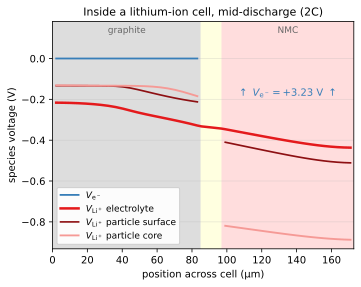

In [8]:
fig, ax = plt.subplots(figsize=(5.4, 4.1), dpi=110)
draw_regions(ax)

ax.plot(x_n * UM, V_e_n, color=C_E, lw=1.8, label=r"$V_{\mathrm{e}^-}$")
# the cathode's V_e- sits ~3.3 V up, far off this scale; annotate it in the
# empty band instead of drawing it
ax.text((L_n + L_s + L_p / 2) * UM, -0.17, r"$\uparrow\ V_{\mathrm{e}^-} = %+.2f$ V $\uparrow$" % np.mean(V_e_p),
        ha='center', va='center', color=C_E, fontsize=10)

ax.plot(x_e * UM, V_li_electrolyte, color=C_LI, lw=2.5, label=r"$V_{\mathrm{Li}^+}$ electrolyte")
for xx, surf, core in [(x_n, V_li_n_surf, V_li_n_core), (x_p, V_li_p_surf, V_li_p_core)]:
    ax.plot(xx * UM, surf, color=C_LI_SURF, lw=1.7)
    ax.plot(xx * UM, core, color=C_LI_CORE, lw=1.9)
ax.plot([], [], color=C_LI_SURF, lw=1.7, label=r"$V_{\mathrm{Li}^+}$ particle surface")
ax.plot([], [], color=C_LI_CORE, lw=1.9, label=r"$V_{\mathrm{Li}^+}$ particle core")

ax.set_xlabel("position across cell (μm)")
ax.set_ylabel("species voltage (V)")
ax.set_title("Inside a lithium-ion cell, mid-discharge (2C)", fontsize=11)
headroom(ax)
ax.legend(loc='lower left', fontsize=9, framealpha=0.9)
save_book_svg(fig, 'pybamm_dfn_landscape.svg')
plt.show()

The cathode's $V_{\mathrm{e}^-}$ sits about $+3.3$ V above everything else (it would blow out the vertical scale, hence the annotation): that gap is the cell's terminal voltage. All the discharge losses live in the fine structure of $V_{\mathrm{Li}^+}$, so let's zoom in:

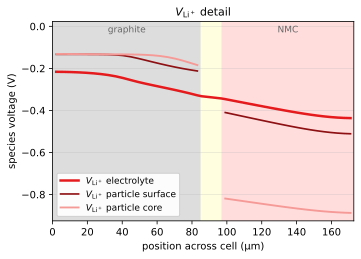

In [9]:
fig, ax = plt.subplots(figsize=(5.4, 3.6), dpi=110)
draw_regions(ax)

ax.plot(x_e * UM, V_li_electrolyte, color=C_LI, lw=2.5, label=r"$V_{\mathrm{Li}^+}$ electrolyte")
for xx, surf, core in [(x_n, V_li_n_surf, V_li_n_core), (x_p, V_li_p_surf, V_li_p_core)]:
    ax.plot(xx * UM, surf, color=C_LI_SURF, lw=1.7)
    ax.plot(xx * UM, core, color=C_LI_CORE, lw=1.9)
ax.plot([], [], color=C_LI_SURF, lw=1.7, label=r"$V_{\mathrm{Li}^+}$ particle surface")
ax.plot([], [], color=C_LI_CORE, lw=1.9, label=r"$V_{\mathrm{Li}^+}$ particle core")

ax.set_xlabel("position across cell (μm)")
ax.set_ylabel("species voltage (V)")
ax.set_title(r"$V_{\mathrm{Li}^+}$ detail", fontsize=11)
headroom(ax)
ax.legend(loc='lower left', fontsize=9, framealpha=0.9)
save_book_svg(fig, 'pybamm_dfn_landscape_zoom.svg')
plt.show()

Reading the landscape (at equilibrium every one of these lines would be a single flat level):

* At the far left of the anode, core and surface $V_{\mathrm{Li}^+}$ still agree: those graphite particles are barely being used yet. Approaching the separator, the surface level drops away from the core as particles are worked harder, and the near-separator particles are draining fastest.
* The roughly constant step between particle surface and electrolyte is the Butler-Volmer activation step of [interface kinetics](https://marklundeberg.com/esbd/kinetics/): even a small interfacial current costs a finite $V_{\mathrm{Li}^+}$ step.
* The electrolyte's $V_{\mathrm{Li}^+}$ slopes wherever it carries current through narrow, twisty pores (steepest inside the electrodes), and flattens across the more open separator.
* In the cathode, every particle shows a large core-to-surface drop: intercalation into NMC is limited by slow solid-state diffusion, and the surfaces of the near-separator particles have nearly saturated with lithium.

The book's [lithium-ion topic](https://marklundeberg.com/esbd/lib/) walks through these mechanisms in more detail.

### Inside one particle

The landscape reduced each particle to its core and surface values, but the DFN carries the whole radial profile, so we can also draw $V_{\mathrm{Li}^+}(r)$ *within* a single particle: the simulated counterpart of the qualitative particle diagram in the book. Take a hard-working anode particle near the separator ($x \approx 79$ μm). The lithium level falls from core to surface as the particle drains through its slow solid-state diffusion, while $V_{\mathrm{e}^-}$ spans the particle as one flat value; past the surface, $V_{\mathrm{Li}^+}$ drops to the local electrolyte level in a single step, since the DFN folds the SEI and the interface kinetics into one Butler-Volmer jump.

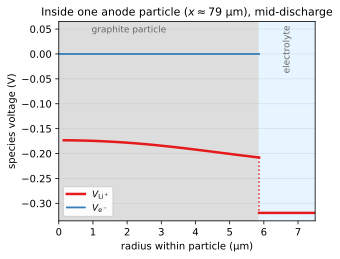

In [10]:
ix = np.argmin(np.abs(x_n - 80e-6))          # anode particle near the separator
R_n = param["Negative particle radius [m]"]
r = solution["r_n [m]"].entries[:, ix, it]   # radial grid (cell centers)
c_s_r = c_s_n[:, ix]
# extend to the true surface using the extrapolated surface concentration
c_surf = solution["Negative particle surface concentration [mol.m-3]"].entries[ix, it]
r_full = np.append(r, R_n)
V_li_r = phi_s_n[ix] - U_n(np.append(c_s_r, c_surf) / c_n_max)
V_e_here = phi_s_n[ix]
V_li_elec_here = np.interp(x_n[ix], x_e, phi_e)

fig, ax = plt.subplots(figsize=(4.6, 3.6), dpi=110)
r_out = R_n * 1.28                           # a stub of electrolyte beyond the surface
ax.axvspan(0, R_n * UM, color='#DDDDDD', zorder=0)
ax.axvspan(R_n * UM, r_out * UM, color='#E6F5FF', zorder=0)
ax.grid(True, axis='y', alpha=0.3, zorder=0)

ax.plot(r_full * UM, V_li_r, color=C_LI, lw=2.5, label=r"$V_{\mathrm{Li}^+}$")
ax.plot([0, R_n * UM], [V_e_here, V_e_here], color=C_E, lw=1.8, label=r"$V_{\mathrm{e}^-}$")
ax.plot([R_n * UM, R_n * UM], [V_li_r[-1], V_li_elec_here], color=C_LI, lw=1.5, ls=':')
ax.plot([R_n * UM, r_out * UM], [V_li_elec_here, V_li_elec_here], color=C_LI, lw=2.5)

ax.text(0.35 * R_n * UM, 0.98, 'graphite particle', transform=ax.get_xaxis_transform(),
        ha='center', va='top', fontsize=9, color='#666666')
ax.text((R_n + (r_out - R_n) / 2) * UM, 0.98, 'electrolyte', transform=ax.get_xaxis_transform(),
        ha='center', va='top', fontsize=9, color='#666666', rotation=90)
ax.set_xlim(0, r_out * UM)
ax.set_xlabel("radius within particle (μm)")
ax.set_ylabel("species voltage (V)")
ax.set_title(r"Inside one anode particle ($x \approx 79$ μm), mid-discharge", fontsize=11)
headroom(ax)
ax.legend(loc='lower left', fontsize=9, framealpha=0.9)
plt.show()

The zero-flux center shows up as the flat slope at $r = 0$, and the widening $V_{\mathrm{Li}^+}$-to-$V_{\mathrm{e}^-}$ gap toward the surface is the surface being more delithiated than the core. The same plot for a near-separator cathode particle (swap in the positive-electrode variables) shows the far more dramatic version: there the core-to-surface drop reaches several hundred millivolts.

## 4. The spectator anion

The electrolyte is a binary solution: $\mathrm{Li}^+$ plus a counterion, $\mathrm{PF}_6^-$, which is blocked at both electrodes and reacts with nothing. It has a species voltage too. The salt's chemical potential varies with composition as $\mathrm{d}\mu_{\mathrm{salt}} = 2RT\cdot\mathrm{TF}\,\mathrm{d}\ln c_e$, where $\mathrm{TF}$ is the thermodynamic factor, and splitting off $\bar\mu_{\mathrm{Li}^+}$ gives

$$ V_{\mathrm{PF}_6^-} = \frac{\bar\mu_{\mathrm{PF}_6^-}}{-F} = \phi_e - \frac{2RT}{F}\int_{c_{\mathrm{ref}}}^{c_e} \mathrm{TF}\,\mathrm{d}\ln c' + \text{const}. $$

This parameter set has $\mathrm{TF} = 1$, so the integral collapses to $\ln(c_e/c_{\mathrm{ref}})$; the integral form is the honest one to use when your parameter set includes real activity data. The constant contains the salt's formation energy: the true vertical gap between $V_{\mathrm{Li}^+}$ and $V_{\mathrm{PF}_6^-}$ is a physical quantity several volts wide, but the DFN never needs it, so we draw the anion level floating, anchored to $\phi_e$ at $c_{\mathrm{ref}} = 1$ mol/L. Only its shape is meaningful.

A blocked species with nowhere to go should, in steady state, have a perfectly flat $V_i$: any slope in $V_{\mathrm{PF}_6^-}$ is a force on the anions, and they are free to redistribute until it vanishes. Let's look:

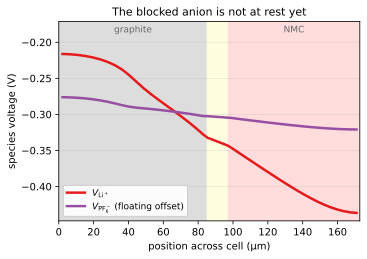

In [11]:
def salt_activity_term(c):
    """(2RT/F) * integral from c_ref to c of TF d(ln c').  TF = 1 here, so this
    equals (2RT/F)*ln(c/c_ref); written as an integral for parameter sets with
    concentration-dependent thermodynamic factors."""
    grid = np.linspace(np.log(min(c.min(), c_ref)) - 0.01, np.log(max(c.max(), c_ref)) + 0.01, 400)
    tf = TF(np.exp(grid), T) if callable(TF) else TF * np.ones_like(grid)
    cum = np.concatenate([[0.0], np.cumsum((tf[1:] + tf[:-1]) / 2 * np.diff(grid))])
    return (2 * R * T / F) * (np.interp(np.log(c), grid, cum) - np.interp(np.log(c_ref), grid, cum))

V_pf6 = phi_e - salt_activity_term(c_e)

fig, ax = plt.subplots(figsize=(5.4, 3.6), dpi=110)
draw_regions(ax)
ax.plot(x_e * UM, V_li_electrolyte, color=C_LI, lw=2.5, label=r"$V_{\mathrm{Li}^+}$")
ax.plot(x_e * UM, V_pf6, color=C_PF6, lw=2.5, label=r"$V_{\mathrm{PF}_6^-}$ (floating offset)")
ax.set_xlabel("position across cell (μm)")
ax.set_ylabel("species voltage (V)")
ax.set_title("The blocked anion is not at rest yet", fontsize=11)
headroom(ax)
ax.legend(loc='lower left', fontsize=9, framealpha=0.9)
plt.show()

Not flat. I expected it to be, and it surprised me; the resolution is that this cell never reaches a transport steady state. The anion level's slope is the leftover force still herding $\mathrm{PF}_6^-$ toward the anode side, where the salt is piling up. How long would it take to finish the job? A quick estimate: compare the salt-diffusion length $\sqrt{D_{\mathrm{eff}} t}$ against the cell thickness, using the porosity-corrected diffusivity inside the electrodes.

In [12]:
D_bulk = float(param["Electrolyte diffusivity [m2.s-1]"](c_ref, T))

# porosity/tortuosity correction, averaged per region at the snapshot time
tors = {dom: np.mean(solution[f"{dom} electrolyte transport efficiency"].entries[:, it])
        for dom in ["Negative", "Separator", "Positive"]}
D_eff_min = D_bulk * min(tors["Negative"], tors["Positive"])
L_total = L_n + L_s + L_p

print(f"bulk electrolyte diffusivity: {D_bulk:.2e} m^2/s")
print("transport efficiencies:", {k: round(v, 3) for k, v in tors.items()})
print(f"diffusion length sqrt(D_eff * t) at t = {t_snap:.0f} s: "
      f"{np.sqrt(D_eff_min * t_snap) * 1e6:.0f} um  vs  cell thickness {L_total * 1e6:.0f} um")

bulk electrolyte diffusivity: 1.77e-10 m^2/s
transport efficiencies: {'Negative': np.float64(0.125), 'Separator': np.float64(0.322), 'Positive': np.float64(0.194)}
diffusion length sqrt(D_eff * t) at t = 1095 s: 156 um  vs  cell thickness 173 um


The diffusion length is only just approaching the cell thickness at our snapshot, so the concentration profile (and with it the anion level) is still developing on the timescale of the entire discharge. Watching both evolve makes the point directly. (The anion curves are drawn re-centered at each time: the electrolyte's overall level also drifts downward as the discharge proceeds, which would bury the shape change we care about.)

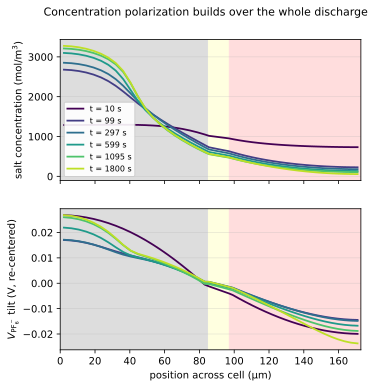

In [13]:
times = [10, 100, 300, 600, 1100, 1800]
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5.4, 5.6), dpi=110, sharex=True)
colors = plt.cm.viridis(np.linspace(0, 0.9, len(times)))

for tv, col in zip(times, colors):
    jt = np.argmin(np.abs(solution.t - tv))
    c_t = solution["Electrolyte concentration [mol.m-3]"].entries[:, jt]
    phi_t = solution["Electrolyte potential [V]"].entries[:, jt]
    x_t = solution["x [m]"].entries[:, jt]
    ax1.plot(x_t * UM, c_t, color=col, lw=1.8, label=f"t = {solution.t[jt]:.0f} s")
    v_a = phi_t - salt_activity_term(c_t)
    ax2.plot(x_t * UM, v_a - v_a.mean(), color=col, lw=1.8)

draw_regions(ax1, labels=False)
draw_regions(ax2, labels=False)
ax1.set_ylabel(r"salt concentration (mol/m$^3$)")
ax1.legend(fontsize=8, loc='lower left', framealpha=0.9)
ax2.set_ylabel(r"$V_{\mathrm{PF}_6^-}$ tilt (V, re-centered)")
ax2.set_xlabel("position across cell (μm)")
fig.suptitle("Concentration polarization builds over the whole discharge", fontsize=11, y=0.96)
plt.show()

The two panels tell the story together. At $t = 10$ s the salt is still nearly uniform, so the anions feel the full switch-on electric field: that first snapshot has the *steepest* tilt of all. The developing concentration gradient then cancels most of the force, and by a few hundred seconds the anion level has flattened considerably through the middle of the cell; this is the relaxation toward the flat steady state that a blocked species demands. It never finishes. The cathode side keeps draining (down toward $100$ mol/m³ by the end), so the level re-steepens near the right edge even as the rest settles. The same depletion drags down the local electrolyte conductivity, one of the compounding losses of fast discharge.

## 5. The recipe, all in one place

For any solved PyBaMM lithium-ion simulation (in the standard gauge: potentials referenced to the negative terminal, OCPs tabulated versus $\mathrm{Li}/\mathrm{Li}^+$):

| species voltage | from DFN variables |
| --- | --- |
| $V_{\mathrm{e}^-}(x)$ | $\phi_s$ |
| $V_{\mathrm{Li}^+}(x)$ in electrolyte | $\phi_e$ |
| $V_{\mathrm{Li}^+}(x, r)$ in particles | $\phi_s - U(c_s(x, r))$ |
| $V_{\mathrm{PF}_6^-}(x)$ | $\phi_e - \frac{2RT}{F}\int_{c_{\mathrm{ref}}}^{c_e}\mathrm{TF}\,\mathrm{d}\ln c'$ + const |

Packed into one function:

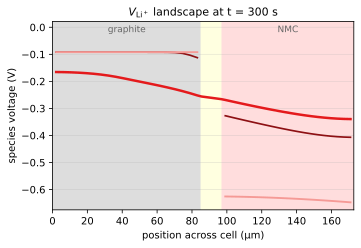

In [14]:
def species_voltages(solution, param, t):
    """Species-voltage landscape from a solved PyBaMM lithium-ion simulation
    at time t [s]. Returns {name: (x [m], V [V])}. Gauge: V_e- = 0 at the
    negative terminal, mu_Li(metal) = 0."""
    it = np.argmin(np.abs(solution.t - t))
    T = param["Ambient temperature [K]"]
    out = {}
    x_e = solution["x [m]"].entries[:, it]
    phi_e = solution["Electrolyte potential [V]"].entries[:, it]
    c_e = solution["Electrolyte concentration [mol.m-3]"].entries[:, it]
    out["V_Li+ electrolyte"] = (x_e, phi_e)
    out["V_PF6- (floating)"] = (x_e, phi_e - salt_activity_term(c_e))
    for dom, sign in [("Negative", "n"), ("Positive", "p")]:
        x_s = solution[f"x_{sign} [m]"].entries[:, it]
        phi_s = solution[f"{dom} electrode potential [V]"].entries[:, it]
        c_s = solution[f"{dom} particle concentration [mol.m-3]"].entries[:, :, it]
        U = param[f"{dom} electrode OCP [V]"]
        c_max = param[f"Maximum concentration in {dom.lower()} electrode [mol.m-3]"]
        out[f"V_e- {sign}"] = (x_s, phi_s)
        out[f"V_Li+ {sign} surface"] = (x_s, phi_s - U(c_s[-1] / c_max))
        out[f"V_Li+ {sign} core"] = (x_s, phi_s - U(c_s[0] / c_max))
    return out

# plug-and-play: the same landscape early in the discharge, when the anode
# is still barely touched and the electrolyte gradients are shallow
V = species_voltages(solution, param, t=300)
fig, ax = plt.subplots(figsize=(5.4, 3.4), dpi=110)
draw_regions(ax)
styles = {"V_Li+ electrolyte": (C_LI, 2.5), "V_Li+ n surface": (C_LI_SURF, 1.7),
          "V_Li+ p surface": (C_LI_SURF, 1.7), "V_Li+ n core": (C_LI_CORE, 1.9),
          "V_Li+ p core": (C_LI_CORE, 1.9)}
for name, (col, lw) in styles.items():
    x, v = V[name]
    ax.plot(x * UM, v, color=col, lw=lw)
ax.set_xlabel("position across cell (μm)")
ax.set_ylabel("species voltage (V)")
ax.set_title(r"$V_{\mathrm{Li}^+}$ landscape at t = 300 s", fontsize=11)
headroom(ax)
plt.show()

That's it. Nothing here required new simulation machinery: the DFN already computes species voltages, two of them, under the names "electrode potential" and "electrolyte potential". The conversion work is just recognizing them, adding the OCP shift inside the particles, and letting the whole family share one ladder so that the losses become directly comparable across every material in the cell.

More on all of this in the book: [Band Diagrams for Batteries](https://marklundeberg.com/esbd/), especially the [lithium-ion battery topic](https://marklundeberg.com/esbd/lib/) (where the figures above appear) and the [translation dictionary](https://marklundeberg.com/esbd/translation/) between traditional electrochemical quantities and species voltages.